# Solving CartPole-v1 with PPO (from scratch)

This notebook demonstrates how to solve the CartPole-v1 environment using a custom implementation of the Proximal Policy Optimization (PPO) algorithm in PyTorch. No external RL libraries are used.

---

**Note:** All environment and hyperparameter settings are now collected in a single `CONFIG` dictionary at the top of the notebook. To change the environment or any hyperparameter, simply edit the values in the config cell.

## 1. Install and Import Required Libraries
We will use gymnasium and torch for this implementation.

In [1]:
%pip install stable-baselines3 gymnasium tsilva-notebook-utils==0.0.104 --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
from tsilva_notebook_utils.colab import load_secrets_into_env

_ = load_secrets_into_env([
    'WANDB_API_KEY',
    'NOTIFICATION_URL',
    'NOTIFICATION_AUTH_TOKEN'
])

In [3]:
from wandb import login
login()

wandb: Currently logged in as: tsilva to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 2. Set Up CartPole-v1 Environment
We will initialize the CartPole-v1 environment and display its basic information.

In [4]:
ENV_ID = "CartPole-v1"
#ENV_ID = "Acrobot-v1"
#ENV_ID = "LunarLander-v3"
#ENV_ID = "Pendulum-v1"
#ENV_ID = "MountainCar-v0"

In [5]:
import torch
import torch.nn as nn
import numpy as np
from tsilva_notebook_utils.gymnasium import build_env as _build_env, set_random_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- Config dictionary for all hyperparameters and environment settings ---
def setup_config(env_id):
    common = dict(
        env_id=env_id,         # Environment name
        seed=42,               # Random seed for reproducibility
        gamma=0.99,            # Discount factor for future rewards
        lam=0.95,              # GAE lambda for advantage estimation
        clip_epsilon=0.2,      # PPO clip range for policy update
        minibatch_size=64,     # Minibatch size for SGD
        episodes_per_epoch=20, # Number of episodes per training epoch
        eval_interval=5,       # Evaluate every N epochs
        eval_episodes=20,      # Number of episodes for evaluation
        reward_threshold=200,  # Reward threshold to consider environment solved
        policy_lr=3e-4,        # Learning rate for policy network
        value_lr=1e-3,         # Learning rate for value network
        hidden_dim=64,         # Hidden layer size for networks
        entropy_coef=0.01,     # Coefficient for entropy bonus (encourages exploration)
        normalize=False,       # Whether to use input normalization
        n_envs="auto"          # Maximum number of parallel environments
    )
    env_specific = {
        "CartPole-v1": dict(
            gamma=0.99,           # Standard discount for CartPole
            lam=0.95,             # GAE lambda, balances bias/variance
            clip_epsilon=0.2,     # PPO clip range, stable for CartPole
            minibatch_size=32,    # Smaller batch for faster updates
            episodes_per_epoch=16,# Fewer episodes per epoch for quick feedback
            eval_interval=2,      # Evaluate more frequently for fast convergence
            eval_episodes=10,     # Fewer eval episodes for speed
            reward_threshold=475, # Official CartPole-v1 solved threshold
            policy_lr=3e-4,       # Standard PPO learning rate
            value_lr=1e-3,        # Slightly higher for value net
            hidden_dim=64,        # Small net is sufficient for CartPole
            entropy_coef=0.01     # Typical entropy for CartPole
        ),
        "LunarLander-v3": dict(
            gamma=0.99,           # Standard discount for LunarLander
            lam=0.95,             # GAE lambda, balances bias/variance
            clip_epsilon=0.2,     # PPO clip range, stable for LunarLander
            minibatch_size=64,    # Larger batch for more stable updates
            episodes_per_epoch=8, # Fewer episodes per epoch (env is longer)
            eval_interval=2,      # Evaluate every 2 epochs
            eval_episodes=5,      # Fewer eval episodes for speed
            reward_threshold=200, # Solved threshold for LunarLander-v3
            policy_lr=1e-4,       # Lower LR for more complex env
            value_lr=5e-4,        # Lower LR for value net
            hidden_dim=128,       # Larger net for more complex env
            entropy_coef=0.02     # Higher entropy for more exploration
        ),
        "Acrobot-v1": dict(
            gamma=0.99,           # Standard discount for Acrobot
            lam=0.95,             # GAE lambda, balances bias/variance
            clip_epsilon=0.2,     # PPO clip range, stable for Acrobot
            minibatch_size=32,    # Smaller batch for faster updates
            episodes_per_epoch=16,# Fewer episodes per epoch for quick feedback
            eval_interval=2,      # Evaluate more frequently for fast convergence
            eval_episodes=10,     # Fewer eval episodes for speed
            reward_threshold=-100, # Solved threshold for Acrobot-v1 (average reward > -100)
            policy_lr=3e-4,       # Standard PPO learning rate
            value_lr=1e-3,        # Slightly higher for value net
            hidden_dim=64,        # Small net is sufficient for Acrobot
            entropy_coef=0.01     # Typical entropy for Acrobot
        ),
        "Pendulum-v1": dict(
            gamma=0.99,           # Standard discount for Pendulum
            lam=0.95,             # GAE lambda, balances bias/variance
            clip_epsilon=0.2,     # PPO clip range, stable for Pendulum
            minibatch_size=64,    # Larger batch for continuous action
            episodes_per_epoch=8, # Fewer episodes per epoch (env is longer)
            eval_interval=2,      # Evaluate every 2 epochs
            eval_episodes=5,      # Fewer eval episodes for speed
            reward_threshold=-200, # Solved threshold for Pendulum-v1 (average reward > -200)
            policy_lr=3e-4,       # Standard PPO learning rate
            value_lr=1e-3,        # Slightly higher for value net
            hidden_dim=128,       # Larger net for continuous control
            entropy_coef=0.0      # No entropy for deterministic continuous control
        ),
        "MountainCar-v0": dict(
            gamma=0.99,             # Discount factor (keep)
            lam=0.97,               # Slightly higher GAE lambda for more bias reduction
            clip_epsilon=0.15,      # Tighter PPO clip for more stable updates
            minibatch_size=16,      # Smaller minibatch for more frequent updates
            episodes_per_epoch=24,  # More episodes per epoch for better sampling
            eval_interval=2,        # Keep frequent evaluation
            eval_episodes=10,       # Keep
            reward_threshold=-110,  # Keep
            policy_lr=1e-4,         # Lower learning rate for more stable policy updates
            value_lr=5e-4,          # Lower value net LR for stability
            hidden_dim=128,         # Larger network for more capacity
            entropy_coef=0.05       # Higher entropy for hard exploration
        ),
    }
    if env_id not in env_specific:
        raise ValueError(f"Unsupported env_id: {env_id}")
    return {**common, **env_specific[env_id]}

CONFIG = setup_config(ENV_ID)
CONFIG

Using device: cuda


{'env_id': 'CartPole-v1',
 'seed': 42,
 'gamma': 0.99,
 'lam': 0.95,
 'clip_epsilon': 0.2,
 'minibatch_size': 32,
 'episodes_per_epoch': 16,
 'eval_interval': 2,
 'eval_episodes': 10,
 'reward_threshold': 475,
 'policy_lr': 0.0003,
 'value_lr': 0.001,
 'hidden_dim': 64,
 'entropy_coef': 0.01,
 'normalize': False,
 'n_envs': 'auto'}

In [6]:
# Set random seed for reproducibility
set_random_seed(CONFIG['seed'])

# Wrap build env with config parameters
build_env = lambda seed: _build_env(
    CONFIG['env_id'], 
    norm_obs=CONFIG['normalize'], 
    n_envs=CONFIG['n_envs'], seed=seed
)

# Test building env
env = build_env(CONFIG['seed'])
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)


## 3. Implement PPO Agent
We will define the policy and value networks, and the PPO update step.

In [40]:
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_dim=None):
        super().__init__()
        h = hidden_dim or CONFIG['hidden_dim']
        self.net = nn.Sequential(
            nn.Linear(obs_dim, h), nn.Tanh(),
            nn.Linear(h, h), nn.Tanh(),
            nn.Linear(h, act_dim)
        )
    def forward(self, x):
        return self.net(x)

class ValueNet(nn.Module):
    def __init__(self, obs_dim, hidden_dim=None):
        super().__init__()
        h = hidden_dim or CONFIG['hidden_dim']
        self.net = nn.Sequential(
            nn.Linear(obs_dim, h), nn.Tanh(),
            nn.Linear(h, h), nn.Tanh(),
            nn.Linear(h, 1)
        )
    def forward(self, x):
        return self.net(x)

In [41]:
from __future__ import annotations

from typing import List, Optional, Tuple

import numpy as np
import torch
from torch.distributions import Categorical

# Local helper ------------------------------------------------------
def _get_device(module: torch.nn.Module) -> torch.device:  # type: ignore
    """Return the device of *module*'s first parameter."""
    return next(module.parameters()).device

def collect_rollouts(
    env,
    policy_model: torch.nn.Module,
    value_model: Optional[torch.nn.Module] = None,
    n_episodes: int = 1,
    deterministic: bool = False,
    collect_frames: bool = False,
    compute_advantages: bool = True,
    gamma: float = 0.99,
    gae_lambda: float = 0.95,
):
    if n_episodes < 1:
        raise ValueError("n_episodes must be ≥ 1")

    device = _get_device(policy_model)
    state = env.reset()
    n_envs = env.num_envs

    # Per-env episode buffers ------------------------------------------
    ep_states = [[] for _ in range(n_envs)]
    ep_actions = [[] for _ in range(n_envs)]
    ep_rewards = [[] for _ in range(n_envs)]
    ep_dones = [[] for _ in range(n_envs)]
    ep_logps = [[] for _ in range(n_envs)]
    ep_values = [[] for _ in range(n_envs)] if value_model or compute_advantages else None
    ep_frames = [[] for _ in range(n_envs)] if collect_frames else None

    # Global rollout buffers -------------------------------------------
    states, actions, rewards, dones, logps, values, advantages, frames = ([] for _ in range(8))
    total_ep_returns = []
    episodes_collected = 0

    with torch.no_grad():
        while episodes_collected < n_episodes:
            # ------------------------------------------------ policy forward
            state_t = torch.as_tensor(state, dtype=torch.float32, device=device)
            logits = policy_model(state_t)
            policy_dist = Categorical(logits=logits)

            action_t = policy_dist.probs.argmax(dim=-1) if deterministic else policy_dist.sample()
            logp_tensor = policy_dist.log_prob(action_t)

            action_np = np.atleast_1d(action_t.cpu().numpy())
            logp_np = np.atleast_1d(logp_tensor.cpu().numpy())

            # value prediction is optional -----------------------------
            if value_model is not None: value_np = np.atleast_1d(value_model(state_t).squeeze(-1).cpu().numpy())
            else: value_np = np.zeros(n_envs, dtype=np.float32)

            # ------------------------------------------------ env step
            step_out = env.step(action_np)
            next_state, reward, done, _ = step_out

            reward = np.atleast_1d(reward)        # ensure 1-D

            # -------- explicit reset for Gymnasium VecEnv -------------
            #if done.any() and hasattr(env, "reset_done"):
            #    reset_obs, *_ = env.reset_done()
            #    next_obs[done] = reset_obs
            # ----------------------------------------------------------

            # ------------------------------------------------ frame capture
            if collect_frames:
                frame_batch = env.get_images()
                assert len(frame_batch) == n_envs, "get_images() must return a list of length n_envs"
                for i in range(n_envs): ep_frames[i].append(frame_batch[i])  # type: ignore[arg-type]

            # ------------------------------------------------ store transition
            for i in range(n_envs):
                if episodes_collected >= n_episodes:
                    break  # quota reached

                ep_states[i].append(state[i])
                ep_actions[i].append(int(action_np[i]))
                ep_rewards[i].append(float(reward[i]))
                ep_dones[i].append(bool(done[i]))
                ep_logps[i].append(float(logp_np[i]))
                if ep_values is not None: ep_values[i].append(float(value_np[i]))

                if done[i]:
                    # ------- episode i terminates --------------------
                    total_ep_returns.append(float(np.sum(ep_rewards[i])))

                    # Compute advantages / returns --------------------
                    if compute_advantages:
                        t_rewards = ep_rewards[i]
                        t_values  = ep_values[i] if ep_values is not None else [0.0] * len(t_rewards)
                        T = len(t_rewards)
                        adv = [0.0] * T
                        ret = [0.0] * T
                        last_gae = 0.0
                        next_value = 0.0  # because episode ended
                        for t in reversed(range(T)):
                            delta = t_rewards[t] + gamma * next_value - t_values[t]
                            last_gae = delta + gamma * gae_lambda * last_gae
                            adv[t] = last_gae
                            next_value = t_values[t]
                            
                        # returns-to-go (Monte Carlo)
                        running_ret = 0.0
                        for t in reversed(range(T)):
                            running_ret = t_rewards[t] + gamma * running_ret
                            ret[t] = running_ret
                    else:
                        adv = [0.0] * len(ep_rewards[i])
                        ret = None  # unused

                    # ------- flush episode i -------------------------
                    states.extend(ep_states[i]); ep_states[i].clear()
                    actions.extend(ep_actions[i]); ep_actions[i].clear()
                    rewards.extend(ep_rewards[i]); ep_rewards[i].clear()
                    dones.extend(ep_dones[i]); ep_dones[i].clear()
                    logps.extend(ep_logps[i]); ep_logps[i].clear()
                    if ep_values is not None: values.extend(ep_values[i]); ep_values[i].clear()
                    else: values.extend([0.0] * len(adv))
                    advantages.extend(adv)

                    if collect_frames:
                        frames.append(ep_frames[i].copy())  # type: ignore[arg-type]
                        ep_frames[i].clear()  # type: ignore[union-attr]

                    episodes_collected += 1

            state = next_state  # iterate

    # ------------------------------ return buffers --------------------
    trajectories = (states, actions, rewards, dones, logps, values, advantages)
    return total_ep_returns, trajectories, frames


In [42]:
value_model = ValueNet(obs_dim, hidden_dim=CONFIG['hidden_dim']).to(device) if CONFIG['value_lr'] > 0 else None
policy_model = PolicyNet(obs_dim, act_dim, hidden_dim=CONFIG['hidden_dim']).to(device)

state = env.reset()
n_envs = env.num_envs

# Per-env episode buffers ------------------------------------------
ep_states = [[] for _ in range(n_envs)]
ep_actions = [[] for _ in range(n_envs)]
ep_rewards = [[] for _ in range(n_envs)]
ep_dones = [[] for _ in range(n_envs)]
ep_logps = [[] for _ in range(n_envs)]
ep_values = [[] for _ in range(n_envs)]
ep_frames = [[] for _ in range(n_envs)]

ep_states


BrokenPipeError: [Errno 32] Broken pipe

In [ ]:
state_t = torch.as_tensor(state, dtype=torch.float32, device=device)
state_t.shape, state_t

(torch.Size([12, 4]),
 tensor([[ 0.0144,  0.0323, -0.0057, -0.0273],
         [-0.0221, -0.0221, -0.0078, -0.0496],
         [ 0.0440,  0.0427,  0.0216, -0.0481],
         [ 0.0224,  0.0029,  0.0464, -0.0031],
         [ 0.0295, -0.0445,  0.0230,  0.0273],
         [ 0.0054,  0.0322,  0.0111, -0.0066],
         [-0.0025, -0.0123, -0.0320, -0.0151],
         [-0.0128,  0.0219,  0.0433,  0.0068],
         [-0.0172, -0.0375, -0.0389,  0.0485],
         [-0.0346,  0.0249, -0.0097,  0.0491],
         [-0.0383, -0.0421,  0.0483, -0.0436],
         [ 0.0100,  0.0130, -0.0318,  0.0281]], device='cuda:0'))

In [ ]:
logits = policy_model(state_t)
logits.shape, logits

(torch.Size([12, 2]),
 tensor([[-0.2531, -0.0432],
         [-0.2475, -0.0520],
         [-0.2536, -0.0379],
         [-0.2412, -0.0483],
         [-0.2434, -0.0558],
         [-0.2471, -0.0456],
         [-0.2535, -0.0512],
         [-0.2368, -0.0498],
         [-0.2479, -0.0604],
         [-0.2417, -0.0541],
         [-0.2326, -0.0569],
         [-0.2536, -0.0499]], device='cuda:0', grad_fn=<AddmmBackward0>))

In [ ]:
policy_dist = Categorical(logits=logits)
policy_dist

Categorical(logits: torch.Size([12, 2]))

In [ ]:
policy_dist.probs

tensor([[0.4477, 0.5523],
        [0.4513, 0.5487],
        [0.4463, 0.5537],
        [0.4519, 0.5481],
        [0.4532, 0.5468],
        [0.4498, 0.5502],
        [0.4496, 0.5504],
        [0.4534, 0.5466],
        [0.4533, 0.5467],
        [0.4532, 0.5468],
        [0.4562, 0.5438],
        [0.4493, 0.5507]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

policy_dist.probs.argmax(dim=-1)

In [ ]:
def collect_rollouts(env, policy_model, value_model=None, n_episodes=1, deterministic=False, collect_frames=False, device=None):
    # Use the same collect_rollouts utility as before
    from tsilva_notebook_utils.gymnasium import collect_rollouts
    episode_rewards, (states, actions, rewards, dones, logps, values, advantages), frames = collect_rollouts(
        env,
        policy_model,
        value_model=value_model,
        n_episodes=n_episodes,
        deterministic=deterministic,
        collect_frames=collect_frames,
    )
    val_buf_trunc = values[:len(advantages)]
    ret_buf = (np.array(advantages) + np.array(val_buf_trunc)).tolist()
    obs_t = torch.as_tensor(np.array(states[:len(advantages)]), dtype=torch.float32, device=device)
    act_tensor = torch.as_tensor(np.array(actions[:len(advantages)]), dtype=torch.int64, device=device)
    adv_tensor = torch.as_tensor(np.array(advantages), dtype=torch.float32, device=device)
    ret_tensor = torch.as_tensor(np.array(ret_buf), dtype=torch.float32, device=device)
    logp_old_tensor = torch.as_tensor(np.array(logps[:len(advantages)]), dtype=torch.float32, device=device)
    adv_tensor = (adv_tensor - adv_tensor.mean()) / (adv_tensor.std() + 1e-8)
    return episode_rewards, obs_t, act_tensor, adv_tensor, ret_tensor, logp_old_tensor, frames

In [ ]:
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torch.distributions import Categorical

class PPOAgent(pl.LightningModule):
    def __init__(self, obs_dim, act_dim, config):
        super().__init__()
        self.save_hyperparameters()
        self.config = config
        self.policy_model = PolicyNet(obs_dim, act_dim, hidden_dim=config['hidden_dim'])
        self.value_model = ValueNet(obs_dim, hidden_dim=config['hidden_dim'])
        self.entropy_coef = config.get('entropy_coef', 0.0)
        self.clip_epsilon = config['clip_epsilon']
        self.gamma = config['gamma']
        self.lam = config['lam']
        self.minibatch_size = config['minibatch_size']
        self.episodes_per_epoch = config['episodes_per_epoch']
        self.eval_interval = config['eval_interval']
        self.eval_episodes = config['eval_episodes']
        self.reward_threshold = config['reward_threshold']
        self.device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.train_rewards = []
        self.env = build_env(config['seed'])
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.automatic_optimization = False  # Required for manual optimization with multiple optimizers

    def forward(self, x):
        return self.policy_model(x)

    def training_step(self, batch, batch_idx):
        # Manual optimization for multiple optimizers
        opt_policy, opt_value = self.optimizers()
        episode_rewards, obs_t, act_tensor, adv_tensor, ret_tensor, logp_old_tensor = collect_rollouts(self.env, self.policy_model, self.value_model, n_episodes=self.episodes_per_epoch, deterministic=False, device=self.device_type)
        num_samples = len(obs_t)
        policy_losses, value_losses = [], []
        for _ in range(10):
            idx = np.random.permutation(num_samples)
            for start in range(0, num_samples, self.minibatch_size):
                end = min(start + self.minibatch_size, num_samples)
                mb_idx = idx[start:end]
                policy_logits = self.policy_model(obs_t[mb_idx])
                logits_dist = Categorical(logits=policy_logits)
                logp = logits_dist.log_prob(act_tensor[mb_idx])
                ratio = torch.exp(logp - logp_old_tensor[mb_idx])
                surr1 = ratio * adv_tensor[mb_idx]
                surr2 = torch.clamp(ratio, 1 - self.clip_epsilon, 1 + self.clip_epsilon) * adv_tensor[mb_idx]
                entropy = logits_dist.entropy().mean()
                policy_loss = -torch.min(surr1, surr2).mean() - self.entropy_coef * entropy
                value_pred = self.value_model(obs_t[mb_idx]).squeeze()
                value_loss = ((ret_tensor[mb_idx] - value_pred) ** 2).mean()
                # Policy update
                opt_policy.zero_grad()
                self.manual_backward(policy_loss)
                opt_policy.step()
                # Value update
                opt_value.zero_grad()
                self.manual_backward(value_loss)
                opt_value.step()
                policy_losses.append(policy_loss.detach())
                value_losses.append(value_loss.detach())
        mean_policy_loss = torch.stack(policy_losses).mean()
        mean_value_loss = torch.stack(value_losses).mean()
        mean_reward = float(np.mean(episode_rewards))
        self.log('train/mean_reward', mean_reward, prog_bar=True)
        self.log('train/policy_loss', mean_policy_loss)
        self.log('train/value_loss', mean_value_loss)
        self.train_rewards.append(mean_reward)
        # Early stopping if solved
        if mean_reward >= self.reward_threshold:
            self.trainer.should_stop = True
        return mean_policy_loss + mean_value_loss

    def configure_optimizers(self):
        policy_optim = torch.optim.Adam(self.policy_model.parameters(), lr=self.config['policy_lr'])
        value_optim = torch.optim.Adam(self.value_model.parameters(), lr=self.config['value_lr'])
        return [policy_optim, value_optim]

    def train_dataloader(self):
        # Dummy dataloader: just to trigger training_step
        dummy = torch.zeros(1)
        return DataLoader([dummy], batch_size=1)

## 4. Train PPO Agent
We will train the PPO agent on CartPole-v1.

In [9]:
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning.loggers import WandbLogger
ppo_agent = PPOAgent(obs_dim, act_dim, CONFIG)

wandb_logger = WandbLogger(project="your_project_name")
trainer = Trainer(
    logger=wandb_logger,
    max_epochs=200,  # Large enough, will stop early if solved
    callbacks=[EarlyStopping(monitor='train/mean_reward', mode='max', patience=5, stopping_threshold=CONFIG['reward_threshold'])],
    log_every_n_steps=1,
    enable_progress_bar=True,
    accelerator='auto',
    devices=1
)

trainer.fit(ppo_agent)

# After training, retrieve the trained models
policy_model = ppo_agent.policy_model
value_model = ppo_agent.value_model
train_rewards = ppo_agent.train_rewards


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type      | Params | Mode 
---------------------------------------------------
0 | policy_model | PolicyNet | 4.6 K  | train
1 | value_model  | ValueNet  | 4.5 K  | train
---------------------------------------------------
9.2 K     Trainable params
0         Non-trainable params
9.2 K     Total params
0.037     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode

  | Name         | Type      | Params | Mo

Training: |          | 0/? [00:00<?, ?it/s]

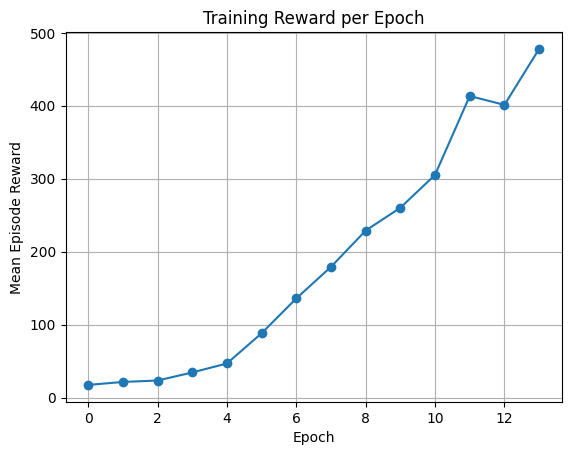

In [10]:
# Plot training rewards after training
import matplotlib.pyplot as plt

plt.plot(train_rewards, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Mean Episode Reward')
plt.title('Training Reward per Epoch')
plt.grid(True)
plt.show()

In [24]:
from tsilva_notebook_utils.gymnasium import render_episode_frames
from tsilva_notebook_utils.gymnasium import collect_rollouts as _collect_rollouts
import random

# TODO: use cuda?
ep_rewards, trajectories, frames = _collect_rollouts(
    build_env(random.randint(0, 1_000_000)),
    policy_model,
    n_episodes=4,
    deterministic=True,
    collect_frames=True
)
mean_reward = float(np.mean(ep_rewards))
print(f"Mean reward: {mean_reward:.2f}")
render_episode_frames(frames, out_dir="./tmp", grid=(2, 2), text_color=(0, 0, 0))

Mean reward: 482.00


- TODO: Consider using RolloutBuffer
- TODO: Adapt for Torch Lightning